In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
plt.rcParams['figure.dpi'] = 75 # we will learn about this later! increase this number for higher-quality images

Let's learn how to recreate this little dashboard: 

<img src='dashboard_tmp.png' width="300" height="300">

What we need is: 
- aggregate data into 1D or 2D distributions 
- create subplots in a particular layout
- adjust the axes limits 
- create a big title for the dashboard 
- set the colors 

## Read in the data

Data about the internet transfer

In [3]:
data = pd.read_csv('ALB_2020-03.csv', index_col=[0])
data['DATE_TIME'] = pd.to_datetime(data['DATE_TIME'])

In [4]:
data.shape

(1048, 4)

In [5]:
data.head()

,CO,DOWNSTREAM,UPSTREAM,DATE_TIME
1149288,ALB,3.176651e+08,5.982221e+07,2020-03-18 00:00:00
1149289,ALB,2.880432e+08,6.382544e+07,2020-03-18 00:15:00
1149290,ALB,2.485370e+08,7.249465e+07,2020-03-18 00:30:00
1149291,ALB,2.247381e+08,6.292295e+07,2020-03-18 00:45:00
1149292,ALB,2.130292e+08,5.540958e+07,2020-03-18 01:00:00


Look how big the numbers are -> order of 1e10. This may cause problems later on - generally better to rescale the data, but let's skip it for now. 

## Creating the histograms

#### Pandas and MPL

In general, for a quick visualization, we can use pandas `df.plot` functionality, which also calls matplotlib and creates the MPL figure for us 

<Axes: xlabel='DATE_TIME'>

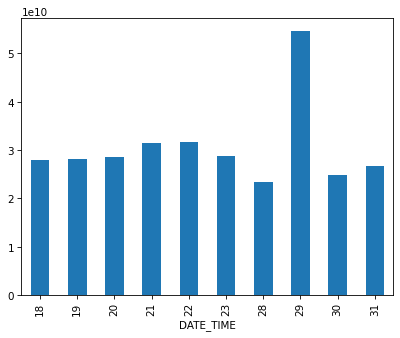

In [6]:
data\
    .groupby(data['DATE_TIME'].dt.day)['DOWNSTREAM']\
    .sum()\
    .plot.bar()

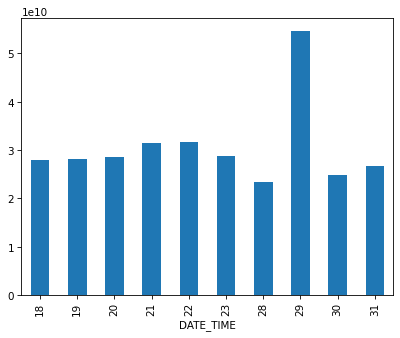

In [7]:
what_is_this = data.groupby(data['DATE_TIME'].dt.day)['DOWNSTREAM'].sum().plot.bar()

In [8]:
type(what_is_this)

matplotlib.axes._axes.Axes

So pandas is providing us with an axes object which we may further use to customize! Pandas plotting function also accepts some (but not all) parameters to customize the figure 

#### Histograms with pandas

For the histogram, we need our data to be aggregated. Different bin sizes reveal different structures - important analytical step is to choose "not too many, not too few"

Luckily, pandas provides histograms out of the box, applying some default styling and sizing: 

<Axes: >

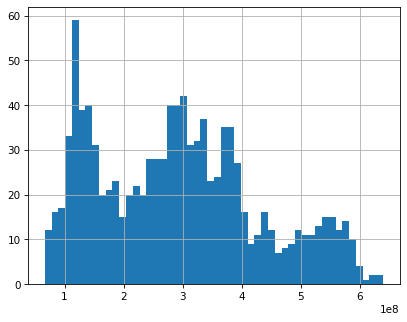

In [9]:
data['DOWNSTREAM'].hist(bins=50, 
                        orientation='vertical')

We don't need to import matplotlib to use pandas API, but if we want to use both of them, we need to import both. We can use pandas with matplotlib objects created manually: 

<Axes: >

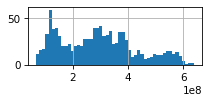

In [10]:
f, ax = plt.subplots(figsize=(3,1))

data['DOWNSTREAM'].hist(bins=50, ax=ax)

Pandas plotting functions also allow you to change the appearance of the chart:

<Axes: >

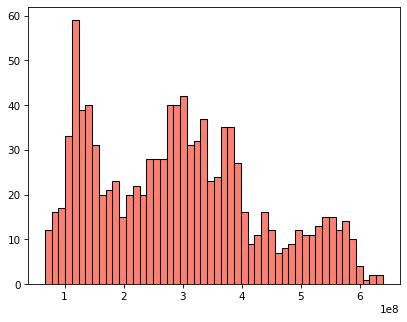

In [11]:
data['DOWNSTREAM'].hist(bins=50, 
                        color='salmon', linewidth=1, edgecolor='k', 
                        grid=False
                       )

#### Histograms with seaborn

How would the same task look like in seaborn? 

In [12]:
import seaborn as sns
print(sns.__version__)

0.13.2


In [13]:
data.head()

,CO,DOWNSTREAM,UPSTREAM,DATE_TIME
1149288,ALB,3.176651e+08,5.982221e+07,2020-03-18 00:00:00
1149289,ALB,2.880432e+08,6.382544e+07,2020-03-18 00:15:00
1149290,ALB,2.485370e+08,7.249465e+07,2020-03-18 00:30:00
1149291,ALB,2.247381e+08,6.292295e+07,2020-03-18 00:45:00
1149292,ALB,2.130292e+08,5.540958e+07,2020-03-18 01:00:00


The approach is somewhat similar to the approach we took with pandas: seaborn will create an MPL figure and axes for you if there is none, but can also plot in the axes you have created independently 

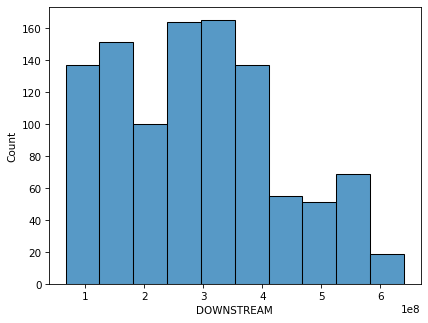

In [14]:
new_ax = sns.histplot(data, x='DOWNSTREAM', bins=10)

<Axes: xlabel='DOWNSTREAM', ylabel='Count'>

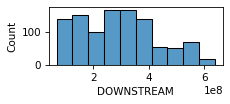

In [15]:
f, ax = plt.subplots(figsize=(3,1))
sns.histplot(data, x='DOWNSTREAM', bins=10, ax=ax)

Seaborn has more in-built statistics functionalities and it can fit the distribution for us: 

In [16]:
# histogram with estimated distribution:

# sns.histplot(data=data, x='DOWNSTREAM', bins=10, kde=True, element="step") 
# sns.histplot(x=data['DOWNSTREAM'], bins=10, kde=True, element="step") # we can also pass a single series 

# rotated histogram: 

# sns.histplot(data=data, y='DOWNSTREAM', bins=10, kde=True, element="step")

Changing the appearance of the chart is done similarly to pandas and MPL:

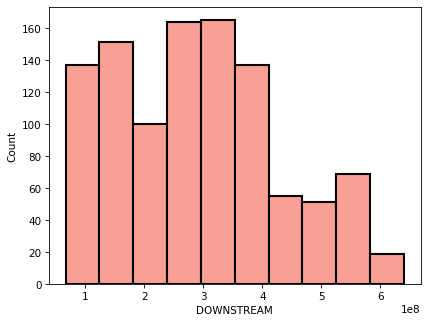

In [17]:
new_ax = sns.histplot(data, x='DOWNSTREAM', bins=10, 
                      color='salmon', linewidth=2)

#### Histograms without pandas or seaborn

Option 1: `ax.hist()` -> https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hist.html 

Option 2: use numpy to create bin edges and bin values manually, then plot binned data as a bar chart. Useful when you need to use another plotting library with very limited functionality, or if there needs to be some special data pre-processing applied.  

In [18]:
nbins = 10
values, bin_edges = np.histogram(data['DOWNSTREAM'], bins=nbins)

In [19]:
print("num. values: {}".format(values.shape))
print("num. bin edges: {}".format(bin_edges.shape)) # we don't need the last bin edge here

num. values: (10,)
num. bin edges: (11,)


We have 1 extra bin edge (the last one) - need to remove it for plotting 

<BarContainer object of 10 artists>

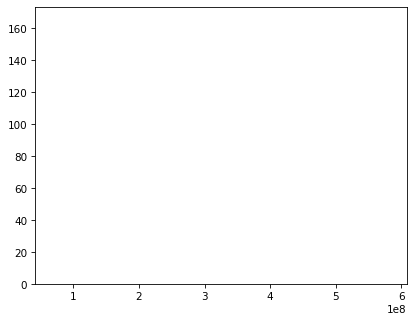

In [20]:
f, ax = plt.subplots()
ax.bar(x=bin_edges[:-1], height=values, ) 

# there is 10 artists, but there is nothing drawn! it's because bar width is in data coordinates (default width=0.8)

Let's define the width of the bar in relation to the data: 

<BarContainer object of 10 artists>

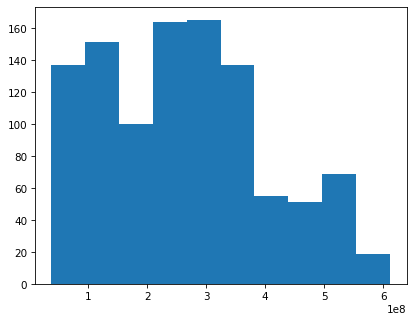

In [21]:
f, ax = plt.subplots()

# barwidth = 1e7 # absolute width 
barwidth = np.diff(bin_edges[:-1]).mean()  # width equal to the bin width 

ax.bar(x=bin_edges[:-1], height=values, width=barwidth)

In our dashboard we have a rotated histogram. Luckily we have another function to draw the horizontal bars: `ax.barh()`. The trick is that we have to swap the argument names!

<BarContainer object of 10 artists>

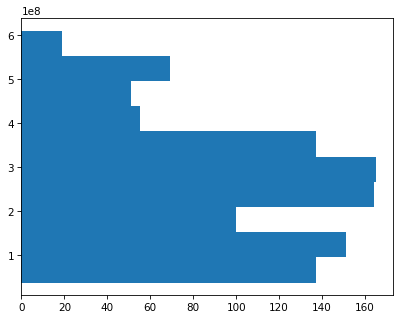

In [22]:
f, ax = plt.subplots()
barwidth = np.diff(bin_edges[:-1]).mean()  # width equal to the bin width 
ax.barh(y=bin_edges[:-1], height=barwidth, width=values) # for barh the height and width are swapped! 

The look of the chart can be customized: 

original y lims: (np.float64(0.0), np.float64(173.25))


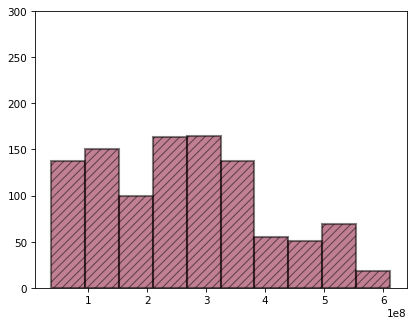

In [23]:
f, ax = plt.subplots()
barwidth = np.diff(bin_edges[:-1]).mean()*1.0  # width equal to the bin width 
ax.bar(x=bin_edges[:-1], height=values, width=barwidth, 
      linewidth=2, edgecolor='k', facecolor='#840128', alpha=0.5, hatch="///", )

print("original y lims: {}".format(ax.get_ylim()))
ax.set_ylim([0,300]);

## 2D histograms 

#### Seaborn

Super easy! You can use the same function, just provide both x and y arguments 

<Axes: xlabel='DOWNSTREAM', ylabel='UPSTREAM'>

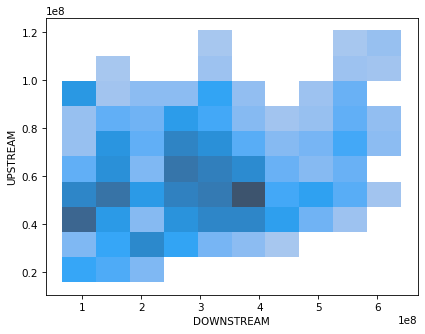

In [24]:
sns.histplot(x=data['DOWNSTREAM'], y=data['UPSTREAM'], bins=10) # for equal number of bins along x and y-axis

# sns.histplot(x=data['DOWNSTREAM'], y=data['UPSTREAM'], bins=(1,10)) for custom number of bins 

We can change the colormap by calling a `cmap` argument.   
List of cmaps: https://matplotlib.org/stable/tutorials/colors/colormaps.html   
We will have another class where we will look at manipulating colors in detail! 

In [25]:
# sns.histplot(x=data['DOWNSTREAM'], y=data['UPSTREAM'], bins=10, 
#             cmap='Greys')

#### Using matplotlib ax.hist2d()

Also easy! and it accepts the same `cmap` argument

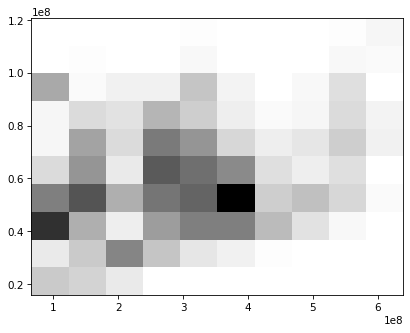

In [26]:
f, ax = plt.subplots()
ax.hist2d(x=data['DOWNSTREAM'], y=data['UPSTREAM'], bins=nbins, 
          cmap='Greys'
         );

To see how to recreate the functionality of `ax.hist2d()` using lower level `ax.imshow()`, scroll to the bottom.

___

# Task: create a dashboard

<img src='dashboard_tmp.png' width="500" >

Use all that you have learned by now to recreate this dashboard. For the title, look up `f.suptitle()` or `ax.set_title(..., loc=..., y=...)`. For the x/y-axis labels, look up `ax.set_xlabel()` and `ax.set_ylabel()` 

In [27]:
# your code here 
# ... 

___

## Bonus: creating a heatmap in matplotlib using numpy and imshow

#### Using matplotlib imshow and numpy 

Let's try to reproduce the heatmap using `ax.imshow()` which is a function to plot 2D images

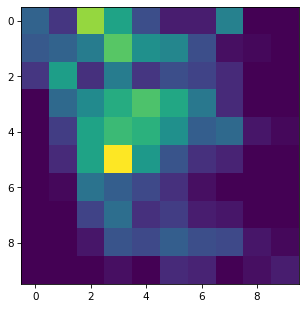

In [28]:
nbins = 10
H, xedges, yedges = np.histogram2d(x=data['DOWNSTREAM'], y=data['UPSTREAM'], bins=nbins)

f, ax = plt.subplots()
ax.imshow(H)

The image is rotated and the axes are scaled with matrix index. Let's add `extent` and `origin` 

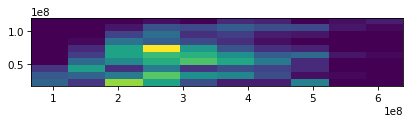

In [29]:
nbins = 10
H, xedges, yedges = np.histogram2d(x=data['DOWNSTREAM'], y=data['UPSTREAM'], bins=nbins)

f, ax = plt.subplots()
ax.imshow(H, 
          extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], #(left, right, bottom, top)
          origin='lower')

Imshow tries to keep the data "square", so that the pixels-per-data density is the same across both axes

However, looking at the previous plots, it's still rotated! why is that? let's investigate

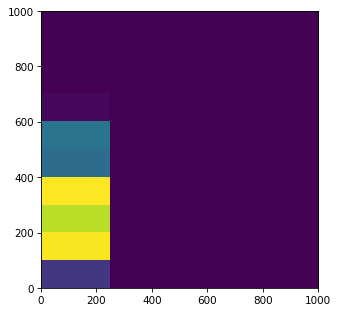

In [30]:
xbins = np.arange(0,1.1e3,1e2) # 10 bins on x 
ybins = np.arange(0,1.1e3,0.25e3) # 4 bins on y 
H, xedges, yedges = np.histogram2d(x=data['DOWNSTREAM']/1e6, y=data['UPSTREAM']/1e6, bins=(xbins, ybins))

f, ax = plt.subplots()
ax.imshow(H, 
          extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], #(left, right, bottom, top)
          origin='lower')

In [31]:
H

array([[ 45.,   0.,   0.,   0.],
       [272.,   0.,   0.,   0.],
       [247.,   0.,   0.,   0.],
       [275.,   0.,   0.,   0.],
       [ 97.,   0.,   0.,   0.],
       [106.,   0.,   0.,   0.],
       [  6.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.]])

In [32]:
# The bi-dimensional histogram of samples x and y. 
#  Values in x are histogrammed along the first dimension and values in y are histogrammed along the second dimension.

H[0] # 4 bins on y, histogramming the x values 

array([45.,  0.,  0.,  0.])

So we need to have a `H.T` instead of `H` as our input matrix! 

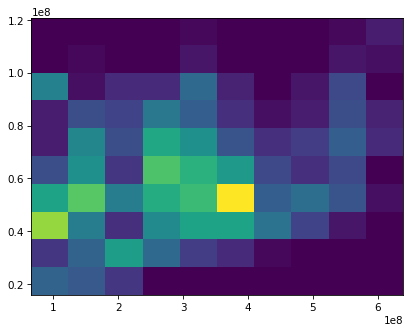

In [33]:
nbins = 10
H, xedges, yedges = np.histogram2d(x=data['DOWNSTREAM'], y=data['UPSTREAM'], bins=nbins)

f, ax = plt.subplots()
ax.imshow(H.T, aspect='auto', 
          extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], #(left, right, bottom, top)
          origin='lower')

___